# EDA de clientes con foco en churn

## Caso practico: Union Central Voz

Este notebook extiende el EDA del dataset de clientes incorporando la variable objetivo `churn`, disponible en `churn_target.csv`.

El objetivo ya no es solo perfilar la cartera, sino estudiar como se relacionan las caracteristicas de cliente con el problema de abandono.

Aun asi, mantenemos una idea metodologica clave: antes de analizar el target, debemos entender bien la estructura de los datos y revisar su calidad.


## Objetivos del notebook

1. Entender la estructura de `clientes.csv` y `churn_target.csv`.
2. Construir una tabla analitica cliente a cliente adecuada para el EDA del churn.
3. Revisar problemas de calidad y coherencia antes de interpretar relaciones.
4. Analizar la distribucion de la variable objetivo y su desbalance.
5. Contrastar hipotesis sencillas sobre el perfil del cliente que churnea.

Este notebook debe leerse como una referencia de trabajo bien estructurada: no pretende agotar el problema, sino sentar una base analitica correcta para fases posteriores de data cleaning, feature engineering y modelado.


## Nota metodologica importante

Las dos tablas no viven en el mismo nivel:

- `clientes.csv` tiene una fila por cliente.
- `churn_target.csv` tiene una estructura temporal cliente-mes.

Eso significa que no podemos hacer una union ingenua y tratar el resultado como si todo estuviera en el mismo nivel.

Para este EDA vamos a construir una etiqueta agregada por cliente:

- `ever_churn = 1` si el cliente churnea al menos una vez en el horizonte observado.
- `ever_churn = 0` en caso contrario.

Esta decision es util para exploracion, pero tiene una limitacion importante: mezcla informacion temporal en una sola etiqueta. Por tanto, sirve para entender perfiles y correlatos, pero no sustituye un diseño de modelado temporal riguroso.


## Hipotesis de partida

Hipotesis H1:
La tasa de churn no deberia ser uniforme entre tipos de plan.

Hipotesis H2:
Clientes con menor antiguedad podrian mostrar mayor propension al churn.

Hipotesis H3:
El churn podria diferir segun tipo de zona o region, porque el contexto territorial suele afectar la experiencia de servicio.

Hipotesis H4:
Variables proxy de valor, como `ingreso_estimado`, `num_lineas` o `descuento_activo`, pueden mostrar patrones diferenciales entre clientes que churnean y los que no.

Hipotesis H5:
El dataset puede contener problemas de calidad que alteren la lectura del churn si no se detectan antes.


In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        'n_missing': df.isna().sum(),
        'pct_missing': df.isna().mean() * 100,
        'dtype': df.dtypes.astype(str)
    })
    return summary.sort_values(['n_missing', 'pct_missing'], ascending=False)


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / max(min(k - 1, r - 1), 1))


def summarize_rate(df: pd.DataFrame, group_col: str, target_col: str = 'ever_churn') -> pd.DataFrame:
    out = (
        df.groupby(group_col)[target_col]
        .agg(['count', 'sum', 'mean'])
        .rename(columns={'count': 'n_clientes', 'sum': 'n_churn', 'mean': 'churn_rate'})
        .sort_values('churn_rate', ascending=False)
    )
    out['churn_rate'] = out['churn_rate'] * 100
    return out


## 1. Carga de datos

Cargamos ambas fuentes y hacemos una primera inspeccion de forma y contenido.


In [3]:
path_clientes = '../data/data_shared/clientes.csv'
path_churn = '../data/churn_target.csv'

clientes = pd.read_csv(path_clientes)
churn = pd.read_csv(path_churn)

print('clientes:', clientes.shape)
print('churn_target:', churn.shape)

display(clientes.head())
display(churn.head())


clientes: (10150, 14)
churn_target: (321987, 3)


,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


## 2. Entendimiento del dato y compatibilidad entre tablas

Antes de unir, conviene responder tres preguntas:

- Cuantos clientes unicos hay en cada fuente.
- Si `cliente_id` permite enlazar correctamente.
- Cual es el horizonte temporal disponible en el target.

Esta verificacion parece simple, pero evita errores de diseno muy frecuentes en proyectos reales.


In [4]:
compat = pd.DataFrame({
    'tabla': ['clientes', 'churn_target'],
    'filas': [len(clientes), len(churn)],
    'clientes_unicos': [clientes['cliente_id'].nunique(), churn['cliente_id'].nunique()]
})

display(compat)

print('Fechas unicas en churn_target:', churn['fecha'].nunique())
print('Min fecha:', churn['fecha'].min())
print('Max fecha:', churn['fecha'].max())


,tabla,filas,clientes_unicos
0,clientes,10150,10000
1,churn_target,321987,10000


Fechas unicas en churn_target: 36
Min fecha: 2023-01-01
Max fecha: 2025-12-01


In [5]:
clientes_ids = set(clientes['cliente_id'])
churn_ids = set(churn['cliente_id'])

print('Clientes en churn y no en clientes:', len(churn_ids - clientes_ids))
print('Clientes en clientes y no en churn:', len(clientes_ids - churn_ids))


Clientes en churn y no en clientes: 0
Clientes en clientes y no en churn: 0


## 3. Diagnostico de calidad del dato

El analisis del churn no debe ocultar una parte esencial del trabajo: revisar si las fuentes tienen problemas que puedan sesgar la interpretacion.

En particular, vamos a revisar:

- Nulos.
- Duplicados.
- Categorias fuera de catalogo.
- Valores imposibles.
- Coherencia basica del target.


In [6]:
display(missing_summary(clientes))


,n_missing,pct_missing,dtype
edad,305,3.00,float64
antiguedad_meses,305,3.00,float64
ingreso_estimado,304,3.00,float64
estado_civil,79,0.78,str
sexo,45,0.44,str
cliente_id,0,0.00,str
zona_id,0,0.00,str
region,0,0.00,str
tipo_zona,0,0.00,str
poblacion_zona,0,0.00,int64


In [7]:
expected_sexo = {'M', 'F'}
expected_estado_civil = {'Soltero/a', 'Casado/a', 'Divorciado/a'}
expected_churn = {0, 1}

quality_checks = {
    'clientes_duplicados_exactos': int(clientes.duplicated().sum()),
    'cliente_id_duplicado': int(clientes['cliente_id'].duplicated().sum()),
    'sexo_fuera_catalogo': int((~clientes['sexo'].isin(expected_sexo)).sum()),
    'estado_civil_fuera_catalogo': int((~clientes['estado_civil'].isin(expected_estado_civil)).sum()),
    'antiguedad_negativa': int((pd.to_numeric(clientes['antiguedad_meses'], errors='coerce') < 0).sum()),
    'zona_id_Z99': int((clientes['zona_id'] == 'Z99').sum()),
    'churn_target_duplicado_cliente_fecha': int(churn.duplicated(subset=['cliente_id', 'fecha']).sum()),
    'churn_fuera_catalogo': int((~pd.to_numeric(churn['churn'], errors='coerce').isin(expected_churn)).sum())
}

display(pd.DataFrame.from_dict(quality_checks, orient='index', columns=['n_casos']))


,n_casos
clientes_duplicados_exactos,150
cliente_id_duplicado,150
sexo_fuera_catalogo,154
estado_civil_fuera_catalogo,153
antiguedad_negativa,145
zona_id_Z99,152
churn_target_duplicado_cliente_fecha,0
churn_fuera_catalogo,0


### Lectura docente

Detectar incidencias en `clientes.csv` es especialmente importante porque, al agregar el target por cliente, cualquier error en esta tabla afecta directamente al perfil de churn.

Por ejemplo:

- Un duplicado puede sobrerrepresentar un segmento.
- Una categoria invalida puede fragmentar artificialmente un grupo.
- Una antiguedad negativa puede alterar medidas de tendencia y dispersion.

La conclusion metodologica es clara: el EDA del churn debe apoyarse en una base analitica minimamente depurada.


## 4. Construccion de la tabla analitica de churn

Vamos a construir una tabla cliente a cliente con los siguientes pasos:

1. Eliminar duplicados exactos en `clientes`.
2. Estandarizar variables con errores evidentes.
3. Agregar `churn_target` para obtener `ever_churn` y algunas referencias temporales.
4. Unir ambas tablas en un solo dataset analitico.

De nuevo, esto no reemplaza un pipeline formal de limpieza. Es una base de trabajo para el EDA.


In [8]:
clientes_eda = clientes.drop_duplicates().copy()

numeric_cols = ['edad', 'poblacion_zona', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'descuento_activo']
for col in numeric_cols:
    clientes_eda[col] = pd.to_numeric(clientes_eda[col], errors='coerce')

clientes_eda.loc[~clientes_eda['sexo'].isin(expected_sexo), 'sexo'] = np.nan
clientes_eda.loc[~clientes_eda['estado_civil'].isin(expected_estado_civil), 'estado_civil'] = np.nan
clientes_eda.loc[clientes_eda['antiguedad_meses'] < 0, 'antiguedad_meses'] = np.nan

churn['fecha'] = pd.to_datetime(churn['fecha'])
churn['churn'] = pd.to_numeric(churn['churn'], errors='coerce')

churn_cliente = (
    churn.groupby('cliente_id')
    .agg(
        ever_churn=('churn', 'max'),
        n_obs_target=('churn', 'size'),
        first_target_month=('fecha', 'min'),
        last_target_month=('fecha', 'max')
    )
    .reset_index()
)

df = clientes_eda.merge(churn_cliente, on='cliente_id', how='left')

print('Filas tabla analitica:', len(df))
print('Clientes sin target:', df['ever_churn'].isna().sum())
display(df.head())


Filas tabla analitica: 10000
Clientes sin target: 0


,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,ever_churn,n_obs_target,first_target_month,last_target_month
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0,0,36,2023-01-01,2025-12-01
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1,0,36,2023-01-01,2025-12-01
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0,1,31,2023-01-01,2025-07-01
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0,0,36,2023-01-01,2025-12-01
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0,0,36,2023-01-01,2025-12-01


## 5. Entendimiento del target

Ahora podemos responder preguntas basicas sobre la variable objetivo:

- Cual es la prevalencia de churn en el horizonte observado.
- Si existe desbalance.
- Cuantas observaciones temporales tiene cada cliente.

Esta parte es esencial porque condiciona la lectura del EDA y cualquier modelado posterior.


In [9]:
target_summary = df['ever_churn'].value_counts(dropna=False).rename_axis('ever_churn').reset_index(name='n_clientes')
target_summary['pct_clientes'] = target_summary['n_clientes'] / len(df) * 100
display(target_summary)

display(df['n_obs_target'].describe())


,ever_churn,n_clientes,pct_clientes
0,0,8000,80.00
1,1,2000,20.00


count   10,000.00
mean        32.20
std          8.78
min          1.00
25%         36.00
50%         36.00
75%         36.00
max         36.00
Name: n_obs_target, dtype: float64

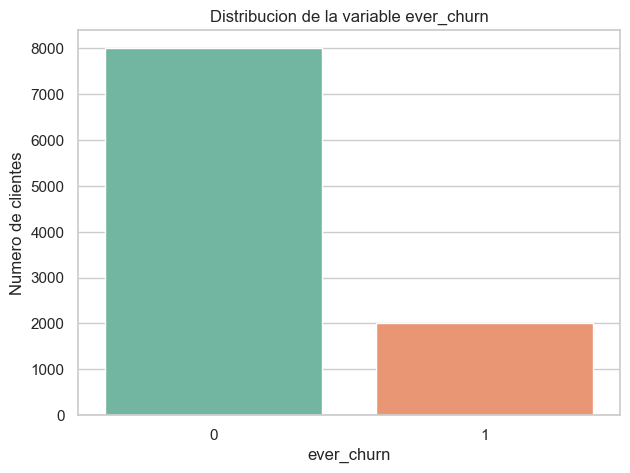

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='ever_churn', palette='Set2')
plt.title('Distribucion de la variable ever_churn')
plt.xlabel('ever_churn')
plt.ylabel('Numero de clientes')
plt.show()


### Interpretacion

Si la clase positiva representa una minoria clara, estamos ante un problema desbalanceado. Esto no impide hacer EDA, pero si condiciona el modelado posterior, la eleccion de metricas y el diseno de validacion.

En un contexto docente, es importante acostumbrarse a separar dos ideas:

- El EDA puede y debe estudiar diferencias entre grupos.
- El modelado posterior necesita cuidar fugas temporales, balanceo y evaluacion realista.


## 6. Perfil general de clientes y churn

Aunque ya hicimos un EDA general del dataset de clientes, aqui repetimos la parte estrictamente necesaria para contextualizar la lectura del churn.

Nos interesa especialmente revisar:

- Variables numericas con potencial explicativo.
- Variables categoricas con posible segmentacion del riesgo.


In [11]:
numerical_cols = ['edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'poblacion_zona']
display(df[numerical_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
edad,"9,700.00",39.34,11.97,18.00,31.00,39.00,47.00,80.00
num_lineas,"10,000.00",2.31,1.02,1.00,2.00,2.00,3.00,5.00
ingreso_estimado,"9,700.00","3,476.79","1,411.89",900.00,"2,466.00","3,219.00","4,194.25","12,000.00"
antiguedad_meses,"9,555.00",33.56,20.98,1.00,18.00,29.00,45.00,120.00
poblacion_zona,"10,000.00","60,004.60","28,724.37","11,707.00","41,163.00","56,342.00","72,683.00","107,159.00"


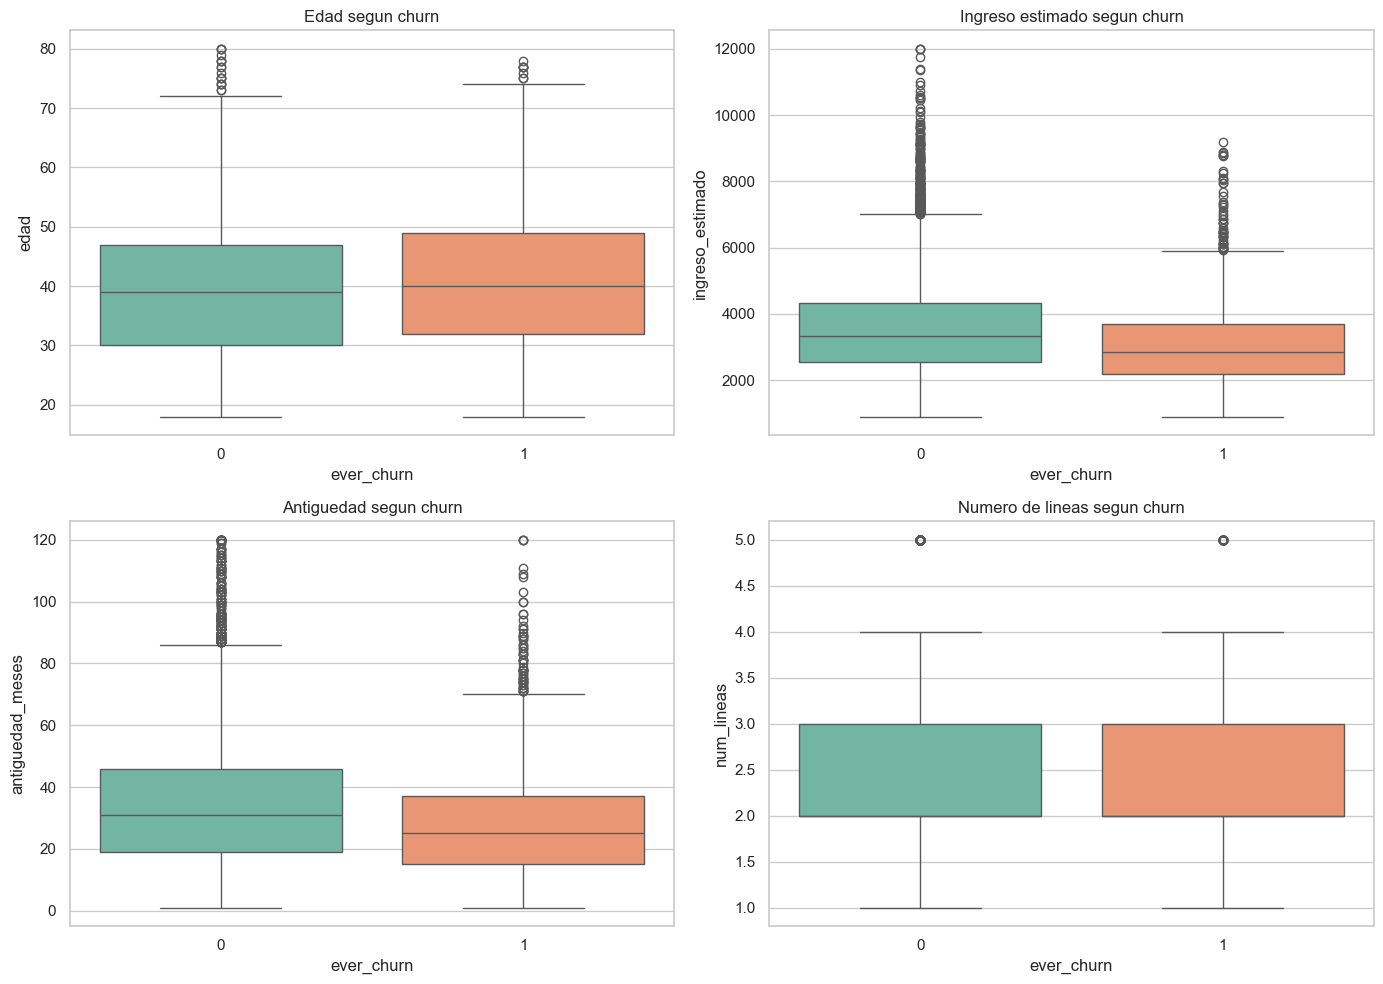

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='ever_churn', y='edad', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Edad segun churn')

sns.boxplot(data=df, x='ever_churn', y='ingreso_estimado', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Ingreso estimado segun churn')

sns.boxplot(data=df, x='ever_churn', y='antiguedad_meses', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Antiguedad segun churn')

sns.boxplot(data=df, x='ever_churn', y='num_lineas', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Numero de lineas segun churn')

plt.tight_layout()


In [13]:
for col in ['tipo_plan', 'tipo_zona', 'region', 'tipo_dispositivo', 'descuento_activo', 'estado_civil', 'sexo']:
    print(f'\n===== {col} =====')
    display(summarize_rate(df.dropna(subset=[col, 'ever_churn']), col))



===== tipo_plan =====


,n_clientes,n_churn,churn_rate
tipo_plan,,,
Prepago,2680,703,26.23
Contrato,2258,484,21.43
Premium,5062,813,16.06



===== tipo_zona =====


,n_clientes,n_churn,churn_rate
tipo_zona,,,
rural,1492,492,32.98
suburbana,4023,859,21.35
urbana_premium,4485,649,14.47



===== region =====


...

,n_clientes,n_churn,churn_rate
descuento_activo,,,
0,7450,1548,20.78
1,2550,452,17.73



===== estado_civil =====


,n_clientes,n_churn,churn_rate
estado_civil,,,
Casado/a,3569,779,21.83
Divorciado/a,777,163,20.98
Soltero/a,5504,1032,18.75



===== sexo =====


,n_clientes,n_churn,churn_rate
sexo,,,
M,4799,971,20.23
F,5051,997,19.74


## 7. Contrastes exploratorios

En este punto ya no solo describimos. Queremos comprobar si algunas diferencias entre clientes con churn y sin churn parecen consistentes.

Usaremos dos tipos de contraste:

- `Mann-Whitney U` para comparar variables numericas entre dos grupos (`ever_churn = 0` frente a `1`).
- `Chi-cuadrado` para estudiar asociacion entre una variable categorica y la etiqueta de churn.

Recordatorio importante: un contraste significativo no prueba causalidad. Solo indica que hay evidencia de una diferencia o asociacion en la muestra.


In [14]:
num_test_results = []

for col in ['edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'poblacion_zona']:
    tmp = df.dropna(subset=[col, 'ever_churn']).copy()
    g0 = tmp.loc[tmp['ever_churn'] == 0, col]
    g1 = tmp.loc[tmp['ever_churn'] == 1, col]
    stat, pvalue = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    num_test_results.append({
        'variable': col,
        'median_churn_0': g0.median(),
        'median_churn_1': g1.median(),
        'statistic': stat,
        'pvalue': pvalue
    })

display(pd.DataFrame(num_test_results).sort_values('pvalue'))


,variable,median_churn_0,median_churn_1,statistic,pvalue
2,ingreso_estimado,"3,338.50","2,843.50","9,261,337.00",0.00
4,poblacion_zona,"56,619.00","53,534.00","9,552,838.50",0.00
3,antiguedad_meses,31.00,25.00,"8,645,729.00",0.00
0,edad,39.00,40.00,"7,012,560.50",0.00
1,num_lineas,2.00,2.00,"8,184,292.50",0.09


In [15]:
cat_test_results = []

for col in ['tipo_plan', 'tipo_zona', 'region', 'tipo_dispositivo', 'descuento_activo', 'estado_civil', 'sexo']:
    tmp = df.dropna(subset=[col, 'ever_churn']).copy()
    table = pd.crosstab(tmp[col], tmp['ever_churn'])
    chi2, pvalue, dof, expected = stats.chi2_contingency(table)
    cat_test_results.append({
        'variable': col,
        'chi2': chi2,
        'pvalue': pvalue,
        'cramers_v': cramers_v(tmp[col], tmp['ever_churn'])
    })

display(pd.DataFrame(cat_test_results).sort_values('pvalue'))


,variable,chi2,pvalue,cramers_v
1,tipo_zona,247.31,0.00,0.16
0,tipo_plan,117.04,0.00,0.11
3,tipo_dispositivo,70.38,0.00,0.08
2,region,28.42,0.00,0.05
4,descuento_activo,10.88,0.00,0.03
5,estado_civil,13.25,0.00,0.04
6,sexo,0.35,0.56,0.01


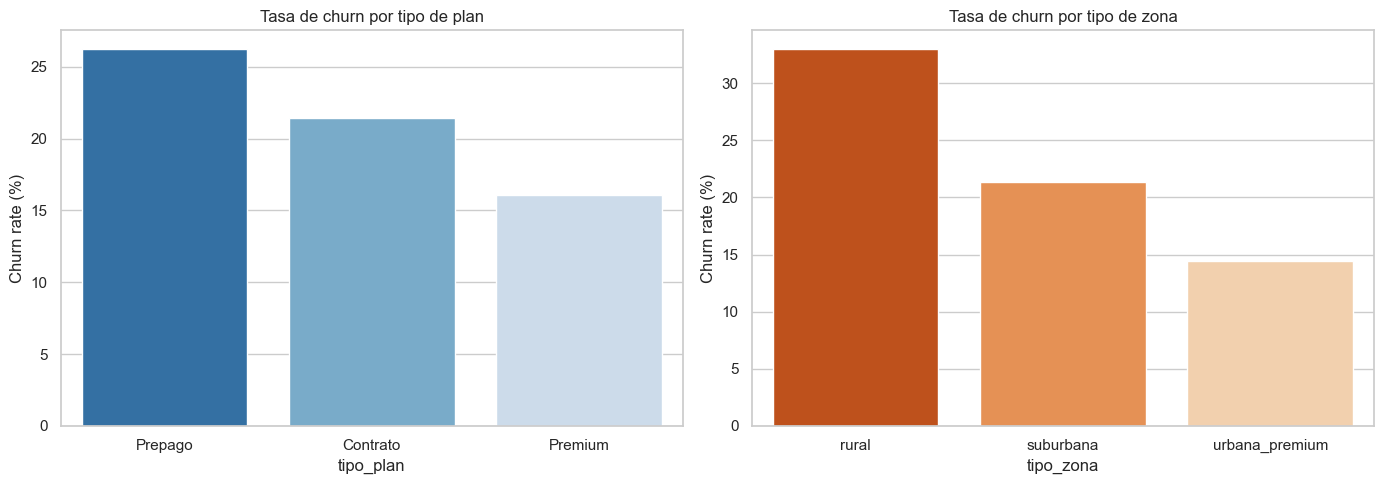

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plan_rate = summarize_rate(df.dropna(subset=['tipo_plan', 'ever_churn']), 'tipo_plan').reset_index()
sns.barplot(data=plan_rate, x='tipo_plan', y='churn_rate', ax=axes[0], palette='Blues_r')
axes[0].set_title('Tasa de churn por tipo de plan')
axes[0].set_ylabel('Churn rate (%)')

zona_rate = summarize_rate(df.dropna(subset=['tipo_zona', 'ever_churn']), 'tipo_zona').reset_index()
sns.barplot(data=zona_rate, x='tipo_zona', y='churn_rate', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Tasa de churn por tipo de zona')
axes[1].set_ylabel('Churn rate (%)')

plt.tight_layout()


## 8. Lectura interpretativa de los resultados

Esta es una seccion muy importante en un notebook docente: no basta con calcular tests. Hay que explicar como leerlos.

Criterios de interpretacion recomendables:

- Un p-valor pequeno sugiere que la diferencia observada no parece compatible con azar bajo la hipotesis nula.
- En variables categoricas, conviene mirar no solo el p-valor sino tambien el tamano del efecto, por ejemplo con `Cramer's V`.
- En variables numericas, la diferencia entre medianas suele ser mas interpretable que la media cuando hay asimetrias o valores extremos.

En este caso, cualquier patron detectado debe leerse como una asociacion exploratoria entre caracteristicas de cliente y churn agregado en el horizonte, no como una relacion causal ni como una prueba de capacidad predictiva fuera de muestra.


## 9. Lectura de negocio

Desde una perspectiva de negocio, este EDA permite empezar a responder preguntas como:

- Que segmentos concentran mayor riesgo relativo de churn.
- Si el churn se asocia con menor antiguedad o con determinados tipos de plan.
- Si hay patrones territoriales que despues deban cruzarse con calidad de red.
- Si variables de valor comercial como `num_lineas` o `descuento_activo` parecen relacionarse con retencion.

Estas conclusiones son solo una primera capa. Para entender realmente el churn del caso, deberemos integrar facturacion, soporte, calidad de senal y encuestas.


## 10. Conclusiones

Conclusiones metodologicas:

- El analisis del churn exige respetar el grano temporal del target.
- Para este EDA, la agregacion a `ever_churn` es util, pero debe declararse explicitamente como simplificacion.
- La calidad del dataset de clientes sigue siendo un punto critico incluso cuando ya disponemos de la variable objetivo.

Conclusiones analiticas:

- Ya es posible perfilar diferencias entre clientes que churnean y los que no.
- Algunas variables de cliente pueden mostrar asociacion con churn y servir como base para analisis posteriores.
- Sin embargo, el verdadero potencial explicativo aparecera al cruzar esta tabla con informacion dinamica y contextual.

Siguiente paso recomendado:

Construir una tabla de modelado temporal evitando leakage, en la que las features se calculen con informacion disponible antes del mes objetivo de churn.
